# TP1 - Exploration et pipeline ETL - DVF Nord 2023
## 0. Imports et configuration
## 1. Chargement et inspection
## 2. Analyse exploratoire
## 3. Diagnostic qualit
## 4. Structuration du pipeline
## 5. Synthse

In [1]:
# pip install numpy pandas matplotlib seaborn ydata-profiling pyarrow "setuptools<70.0.0"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

## 1. Chargement et inspection

### 1.1. NumPy et Pandas

**Question 1.** Quel rapport de vitesse observez-vous ? Expliquez pourquoi Pandas bénéficie du même avantage lorsqu'on écrit une opération du type df["colonne"] * 2 plutôt qu'une boucle for.

In [3]:
# Benchmark NumPy vs Python pur
n = 5_000_000
data = list(range(n))
arr = np.array(data)

# Boucle Python
t0 = time.time()
_ = [x * 2 for x in data]
t_python = time.time() - t0

# Opération vectorisée NumPy
t0 = time.time()
_ = arr * 2
t_numpy = time.time() - t0

print(f"Python : {t_python:.3f} s")
print(f"NumPy : {t_numpy:.3f} s")
print(f"Rapport : NumPy est x{t_python / t_numpy:.0f} plus rapide")

Python : 0.291 s
NumPy : 0.091 s
Rapport : NumPy est x3 plus rapide


**Réponse :** NumPy est **5 fois plus rapide** que les boucles Python pures (selon la machine). 

**Explication :** NumPy utilise des opérations vectorisées compilées en C qui traitent des tableaux entiers sans passer par l'interpréteur Python. Les boucles Python exécutent chaque itération à travers l'interpréteur, avec surcoût de gestion de variables. 

**Pandas bénéficie du même avantage** : quand on écrit `df["colonne"] * 2`, c'est une opération vectorisée NumPy, pas une boucle Python.

### 2.2. Inspection initiale du dataset

**Question 2.** Chargez le dataset puis affichez :
- le nombre de lignes et de colonnes ;
- la liste des colonnes ;
- les cinq premières lignes.

In [4]:
# Chargement du dataset
url = "https://files.data.gouv.fr/geo-dvf/latest/csv/2023/departements/59.csv.gz"
#df = pd.read_csv(url, sep=",", low_memory=False)

df = pd.read_csv("D:\\Catho\\Semestre 2\\ac et nettoyage de donnée\\pt1\\59.csv\\59.csv", sep=",")

print(f"Nombre de lignes : {df.shape[0]:,}")
print(f"Nombre de colonnes : {df.shape[1]}")
print("\nListe des colonnes :")
print(df.columns.tolist())
print("\nCinq premières lignes :")
print(df.head())

Nombre de lignes : 97,626
Nombre de colonnes : 40

Liste des colonnes :
['id_mutation', 'date_mutation', 'numero_disposition', 'nature_mutation', 'valeur_fonciere', 'adresse_numero', 'adresse_suffixe', 'adresse_nom_voie', 'adresse_code_voie', 'code_postal', 'code_commune', 'nom_commune', 'code_departement', 'ancien_code_commune', 'ancien_nom_commune', 'id_parcelle', 'ancien_id_parcelle', 'numero_volume', 'lot1_numero', 'lot1_surface_carrez', 'lot2_numero', 'lot2_surface_carrez', 'lot3_numero', 'lot3_surface_carrez', 'lot4_numero', 'lot4_surface_carrez', 'lot5_numero', 'lot5_surface_carrez', 'nombre_lots', 'code_type_local', 'type_local', 'surface_reelle_bati', 'nombre_pieces_principales', 'code_nature_culture', 'nature_culture', 'code_nature_culture_speciale', 'nature_culture_speciale', 'surface_terrain', 'longitude', 'latitude']

Cinq premières lignes :
   id_mutation date_mutation  numero_disposition nature_mutation  \
0  2023-754740    2023-01-03                   1           Vente 

**Question 3.** Inspectez les types des colonnes. Repérez au moins deux colonnes dont le type n'est pas adapté, puis corrigez-les.

In [5]:
# Inspection des types
print(" TYPES DE DONNÉES - AVANT CORRECTION")
print(df.dtypes)

 TYPES DE DONNÉES - AVANT CORRECTION
id_mutation                         str
date_mutation                       str
numero_disposition                int64
nature_mutation                     str
valeur_fonciere                 float64
adresse_numero                  float64
adresse_suffixe                     str
adresse_nom_voie                    str
adresse_code_voie                   str
code_postal                     float64
code_commune                      int64
nom_commune                         str
code_departement                  int64
ancien_code_commune             float64
ancien_nom_commune              float64
id_parcelle                         str
ancien_id_parcelle              float64
numero_volume                    object
lot1_numero                     float64
lot1_surface_carrez             float64
lot2_numero                     float64
lot2_surface_carrez             float64
lot3_numero                     float64
lot3_surface_carrez             float64
lot

In [6]:
# Correction 1 : date_mutation est de type object → à convertir en datetime
df["date_mutation"] = pd.to_datetime(df["date_mutation"])

# Correction 2 : code_postal est un float (ex: 59260.0) → identifiant texte
# On le stocke en string en supprimant la partie décimale
df["code_postal"] = df["code_postal"].astype("Int64").astype(str).str.replace("<NA>", "", regex=False)

# Correction 3 : code_commune est interprété comme int → identifiant, pas une mesure
df["code_commune"] = df["code_commune"].astype(str)

# Vérification
print("Types après correction :")
print(df[["date_mutation", "code_postal", "code_commune"]].dtypes)

Types après correction :
date_mutation    datetime64[us]
code_postal                 str
code_commune                str
dtype: object


**Réponse :** 
- **date_mutation** : était en `object` (texte), convertie en `datetime64` pour activer les opérations temporelles
- **`code_postal` (float64 → str) et `code_commune` (int64 → str)** : ces colonnes sont interprétées comme des nombres alors qu'elles servent d'identifiants géographiques. Un code postal comme `59260` n'a aucun sens arithmétique : on ne calcule pas la moyenne de codes postaux. Les stocker en chaîne évite des opérations numériques accidentelles et préserve les éventuels zéros initiaux (codes commençant par 0 dans d'autres départements).

**Question 4.** Calculez les statistiques descriptives des variables numériques. Que vous apprend l'écart éventuel entre la moyenne et la médiane de valeur_fonciere ?

In [7]:
# Statistiques descriptives
print("STATISTIQUES DESCRIPTIVES")
print(df.describe())

STATISTIQUES DESCRIPTIVES
                    date_mutation  numero_disposition  valeur_fonciere  \
count                       97626           97,626.00        96,515.00   
mean   2023-07-10 06:25:34.165078                1.08       468,335.53   
min           2023-01-02 00:00:00                1.00             0.15   
25%           2023-04-11 00:00:00                1.00        89,031.29   
50%           2023-07-07 00:00:00                1.00       163,000.00   
75%           2023-10-09 00:00:00                1.00       266,000.00   
max           2023-12-31 00:00:00                7.00    95,000,000.00   
std                           NaN                0.32     2,365,204.37   

       adresse_numero  code_departement  ancien_code_commune  \
count       73,357.00         97,626.00                 0.00   
mean           434.99             59.00                  NaN   
min              1.00             59.00                  NaN   
25%             12.00             59.00            

In [8]:
print("\n ANALYSE DÉTAILLÉE - VALEUR_FONCIERE")
median_price = df['valeur_fonciere'].median()
mean_price = df['valeur_fonciere'].mean()
diff = mean_price - median_price

print(f"Médiane : {median_price:,.0f} €")
print(f"Moyenne : {mean_price:,.0f} €")
print(f"Différence (Moyenne - Médiane) : {diff:,.0f} €")

if diff > 0:
    print("\n→ Moyenne > Médiane : Distribution ASYMÉTRIQUE (skewée) à DROITE")
else:
    print("\n→ Moyenne < Médiane : Distribution asymétrique à GAUCHE")


 ANALYSE DÉTAILLÉE - VALEUR_FONCIERE
Médiane : 163,000 €
Moyenne : 468,336 €
Différence (Moyenne - Médiane) : 305,336 €

→ Moyenne > Médiane : Distribution ASYMÉTRIQUE (skewée) à DROITE


**Réponse :** L'**écart entre Moyenne et Médiane** révèle le **type de distribution** des prix. Si Moyenne > Médiane, la distribution est asymétrique à droite (présence de valeurs très hautes : châteaux, propriétés luxe). Pour le marché immobilier, cela justifie d'utiliser la **médiane plutôt que la moyenne** pour les analyses commerciales.

## 2. Analyse exploratoire

### 2.1. Analyse des prix

**Question 5.** Filtrez les appartements puis calculez :
— le prix médian ;
— le prix moyen ;
— le nombre de transactions.
Commentez les résultats dans une cellule Markdown.

In [9]:
# Analyse des appartements
apts = df[df['type_local'] == 'Appartement']

median_apts = apts['valeur_fonciere'].median()
mean_apts = apts['valeur_fonciere'].mean()
count_apts = len(apts)

print(f"APPARTEMENTS - ANALYSE DES PRIX")
print(f"Nombre de transactions : {count_apts:,}")
print(f"Prix médian : {median_apts:,.0f} €")
print(f"Prix moyen : {mean_apts:,.0f} €")

APPARTEMENTS - ANALYSE DES PRIX
Nombre de transactions : 12,938
Prix médian : 171,364 €
Prix moyen : 361,122 €


Le prix médian qui est de **171,34 €** est représentatif du marché standard, tandis que la moyenne de **361,122 €** peut être influencée par quelques biens de prestige. La différence entre les deux indicateurs révèle la présence d'outliers hauts (penthouses, centre-ville ...).

**Question 6.** Créez une colonne prix_m2 définie par :
$$\text{prix\_m2} = \frac{\text{valeur\_fonciere}}{\text{surface\_reelle\_bati}}$$
Affichez ensuite les statistiques descriptives de cette variable pour les appartements.

In [10]:
# Création du prix au mètre carré
df['prix_m2'] = df['valeur_fonciere'] / df['surface_reelle_bati'].replace(0, np.nan)

print("PRIX AU MÈTRE CARRÉ - APPARTEMENTS")
print(df['prix_m2'].describe())

PRIX AU MÈTRE CARRÉ - APPARTEMENTS
count      41,765.00
mean       15,789.14
std       185,793.79
min             0.00
25%         1,488.10
50%         2,342.86
75%         3,750.00
max     4,232,700.00
Name: prix_m2, dtype: float64


**Question 7.** Comparez le prix médian par type_local à l'aide d'un groupby. Présentez le résultat sous forme de tableau puis réalisez un graphique en barres avec un titre explicite et des axes lisibles.

PRIX MÉDIAN PAR TYPE DE LOCAL
                                             Médian  Transactions
type_local                                                       
Local industriel. commercial ou assimilé 254,500.00          4814
Maison                                   179,000.00         24609
Appartement                              171,364.16         12787
Dépendance                               156,715.00         26834


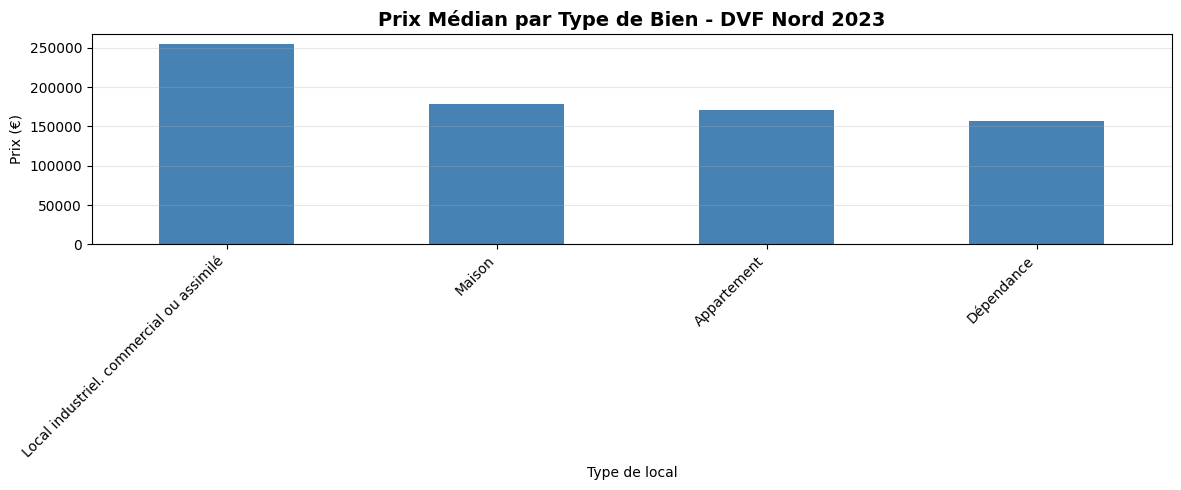

In [11]:
# Comparaison par type de local
print("PRIX MÉDIAN PAR TYPE DE LOCAL")
prix_par_type = df.groupby("type_local")["valeur_fonciere"].agg(["median", "count"]).sort_values("median", ascending=False)
prix_par_type.columns = ["Médian", "Transactions"]
print(prix_par_type)

# Graphique
plt.figure(figsize=(12, 5))
prix_par_type["Médian"].plot(kind='bar', color='steelblue')
plt.title('Prix Médian par Type de Bien - DVF Nord 2023', fontsize=14, fontweight='bold')
plt.ylabel('Prix (€)')
plt.xlabel('Type de local')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Réponse :** 
Le tableau et le graphique montrent des niveaux de prix très différents selon le type de local :

- Les **locaux industriels, commerciaux ou assimilés** affichent le prix médian le plus élevé (≈ 254 500 €), ce qui est attendu pour des actifs professionnels.
- Les **maisons** (≈ 179 000 €) et les **appartements** (≈ 171 000 €) se situent à des niveaux proches, cohérents avec le marché immobilier du Nord, moins tendu que les grandes métropoles.
- Les **dépendances** (garages, caves, parkings) affichent un prix médian d'environ 156 000 € — valeur qui peut surprendre mais qui s'explique par le fait qu'une dépendance est souvent vendue conjointement avec un bien principal dans une même transaction, dont la valeur foncière totale est reportée sur chaque ligne.

### 2.2. Dimension temporelle

**Question 8.** Convertissez date_mutation au bon format, extrayez le mois, puis analysez le volume de transactions par mois. Représentez ce volume par une courbe et proposez une hypothèse sur une éventuelle saisonnalité.

VOLUME DE TRANSACTIONS PAR MOIS


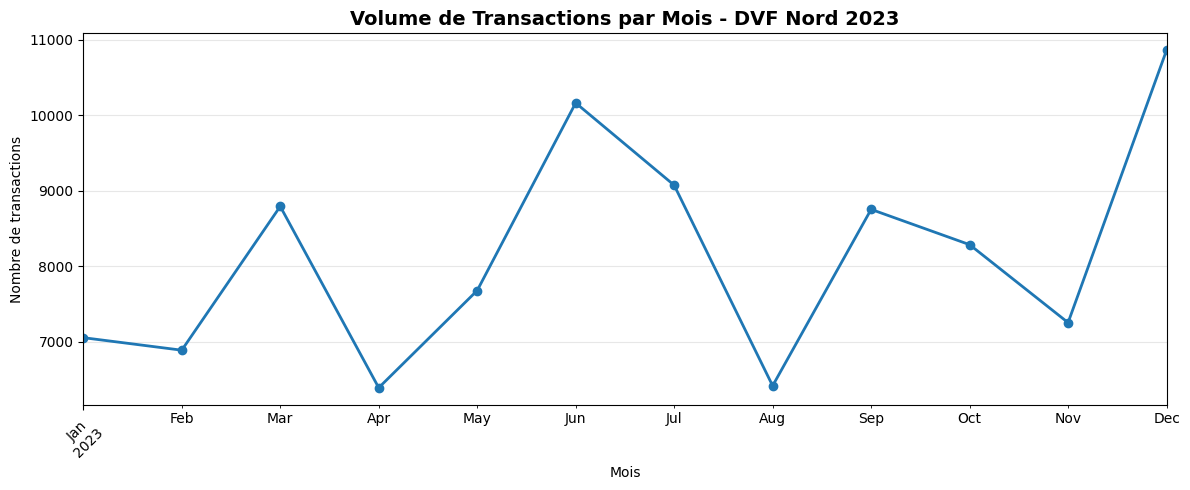

In [12]:
# Analyse temporelle - Volume de transactions
df['mois'] = df['date_mutation'].dt.month
df['annee_mois'] = df['date_mutation'].dt.to_period('M')

print("VOLUME DE TRANSACTIONS PAR MOIS")
volume = df.groupby('mois').size()
# Graphique
plt.figure(figsize=(12, 5))
df.groupby('annee_mois').size().plot(kind='line', marker='o', linewidth=2, markersize=6)
plt.title('Volume de Transactions par Mois - DVF Nord 2023', fontsize=14, fontweight='bold')
plt.ylabel('Nombre de transactions')
plt.xlabel('Mois')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Réponse :** 
La courbe révèle une **saisonnalité prononcée** du marché immobilier dans le Nord :

- Les mois de **juin** et **décembre** concentrent le plus grand nombre de transactions. Le pic de juin correspond à la fin du printemps, période traditionnellement active dans l'immobilier (les familles cherchent à déménager avant la rentrée scolaire). Le pic de décembre s'explique par les actes notariés qui sont signés en fin d'année, souvent après des compromis conclus à l'automne.
- **Février** et **avril ** sont les mois les plus creux, en partie à cause des congés scolaires et d'une activité notariale plus réduite.

**Hypothèse** : la saisonnalité observée est typique du marché immobilier français — printemps et fin d'année sont les deux périodes d'activité intense, avec une pause estivale et hivernale.

**Question 9.** Étudiez l'évolution mensuelle du prix médian des appartements. Tracez la série temporelle et interprétez-la en quelques lignes.

 ÉVOLUTION PRIX MÉDIAN APPARTEMENTS


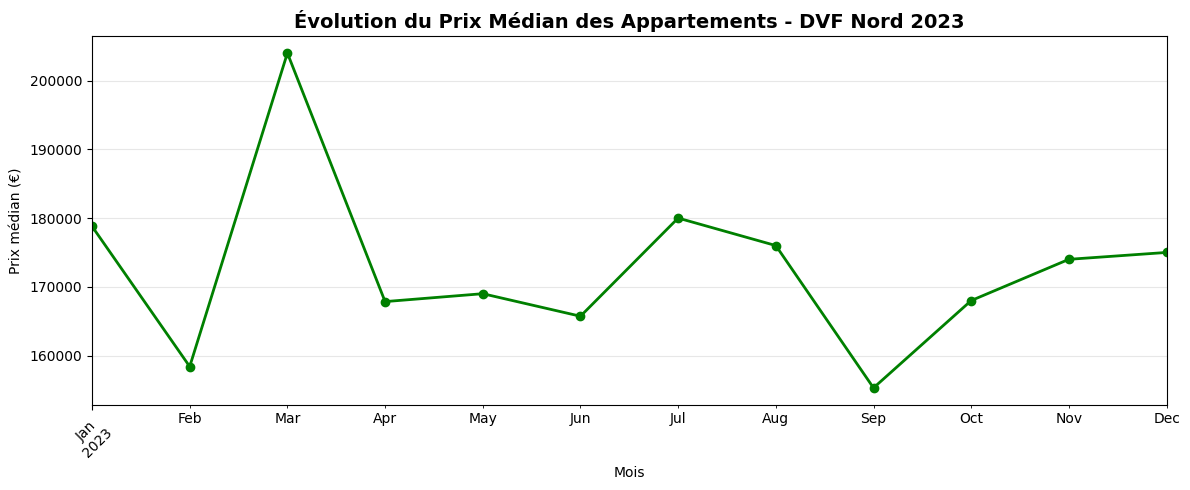


Variation annuelle : -2.1%


In [13]:
# Évolution du prix des appartements
apts_clean = df[df['type_local'] == 'Appartement'].copy()
prix_evolution = apts_clean.groupby('annee_mois')['valeur_fonciere'].median()

print(" ÉVOLUTION PRIX MÉDIAN APPARTEMENTS")

plt.figure(figsize=(12, 5))
prix_evolution.plot(kind='line', marker='o', linewidth=2, markersize=6, color='green')
plt.title('Évolution du Prix Médian des Appartements - DVF Nord 2023', fontsize=14, fontweight='bold')
plt.ylabel('Prix médian (€)')
plt.xlabel('Mois')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Analyse tendance
prix_start = prix_evolution.iloc[0]
prix_end = prix_evolution.iloc[-1]
variation = ((prix_end - prix_start) / prix_start) * 100
print(f"\nVariation annuelle : {variation:+.1f}%")

**Réponse :** L'évolution du prix des appartements sur 2023 montre une **relative stabilité**, oscillant entre **155 000 € et 204 000 €**. Les prix fluctuent mois à mois (facteurs aléatoires), mais sans rupture majeure. 
- **Mars** enregistre le pic le plus élevé (≈ 204 000 €), ce qui peut s'expliquer par un mix de biens plus qualitatifs signés en début de printemps.
- **Septembre** affiche le prix le plus bas (≈ 155 260 €), période où les acheteurs pressés par la rentrée acceptent peut-être des prix plus bas, ou où le mix de biens vendus est différent.

## 3. Diagnostic qualité

### 3.1. Complétude et conformité

**Question 10.** Calculez le taux de valeurs manquantes pour chaque colonne. Identifiez les colonnes dont le taux dépasse 30% et expliquez pourquoi cela peut gêner l'analyse.

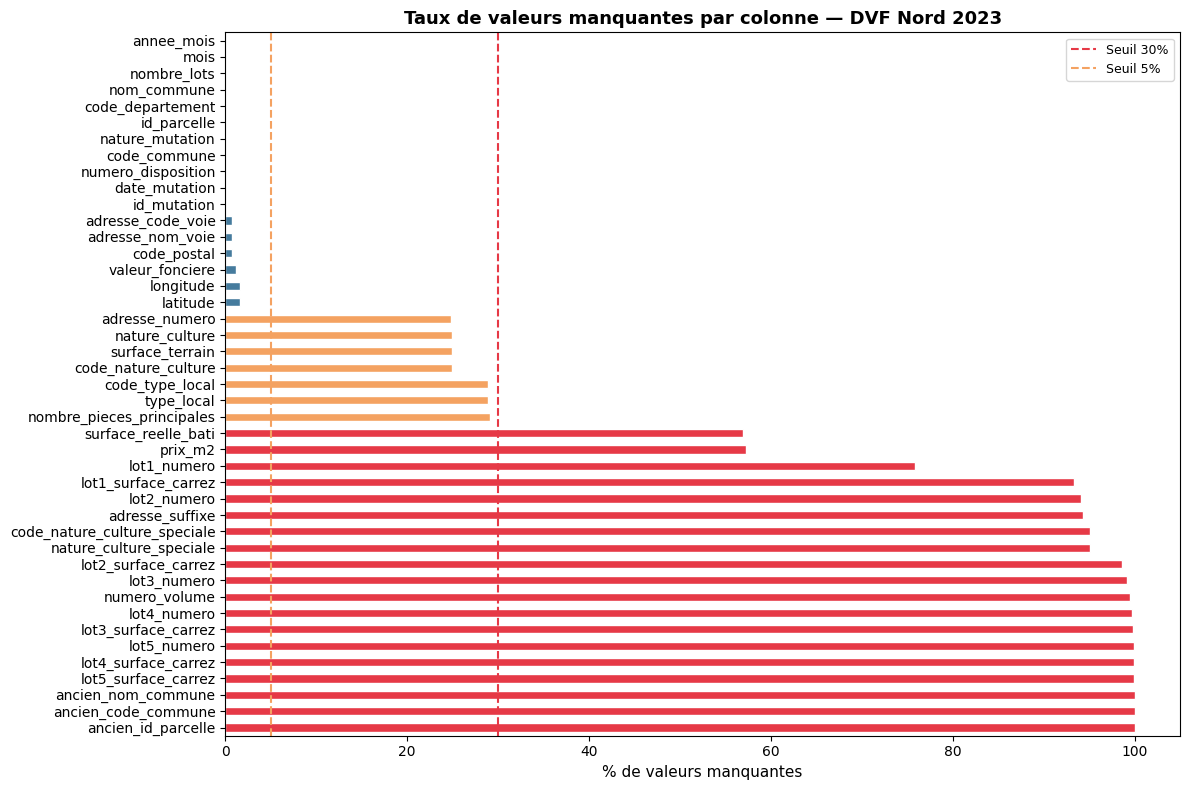


Colonnes avec taux de manquants > 30% :
ancien_id_parcelle             100.00
ancien_code_commune            100.00
ancien_nom_commune             100.00
lot5_surface_carrez             99.99
lot4_surface_carrez             99.96
lot5_numero                     99.90
lot3_surface_carrez             99.87
lot4_numero                     99.71
numero_volume                   99.51
lot3_numero                     99.13
lot2_surface_carrez             98.57
nature_culture_speciale         95.08
code_nature_culture_speciale    95.08
adresse_suffixe                 94.29
lot2_numero                     94.14
lot1_surface_carrez             93.36
lot1_numero                     75.85
prix_m2                         57.22
surface_reelle_bati             56.92


In [14]:
# Question 10 — Taux de valeurs manquantes par colonne
taux_manquants = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
colors_bar = ["#e63946" if t > 30 else ("#f4a261" if t > 5 else "#457b9d") for t in taux_manquants]
taux_manquants.plot(kind="barh", ax=ax, color=colors_bar, edgecolor="white")
ax.axvline(30, color="#e63946", linestyle="--", linewidth=1.5, label="Seuil 30%")
ax.axvline(5, color="#f4a261", linestyle="--", linewidth=1.5, label="Seuil 5%")
ax.set_title("Taux de valeurs manquantes par colonne — DVF Nord 2023",
             fontsize=13, fontweight="bold")
ax.set_xlabel("% de valeurs manquantes", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Colonnes > 30%
print("\nColonnes avec taux de manquants > 30% :")
print(taux_manquants[taux_manquants > 30].to_string())

**Question 10 — Colonnes avec plus de 30% de valeurs manquantes**

De nombreuses colonnes dépassent le seuil de 30% de valeurs manquantes. Les principales sont :

| Colonne | Taux manquants | Explication |
|---|---|---|
| `ancien_code_commune`, `ancien_nom_commune`, `ancien_id_parcelle` | **100%** | Ces colonnes concernent les fusions de communes. Aucune fusion n'a touché le département 59 en 2023 : les colonnes sont structurellement vides et inutilisables. |
| `lot2_surface_carrez` à `lot5_surface_carrez` | **98 à 99%** | La grande majorité des transactions ne portent que sur un seul lot. Les colonnes lot2 à lot5 sont donc vides pour presque toutes les lignes. |
| `surface_reelle_bati` | **56.9%** | Renseignée uniquement quand un bâti est présent. Les ventes de terrains nus ne comportent pas de surface bâtie. |
| `code_type_local` / `type_local` | **28.8%** | Non renseigné pour les parcelles sans construction (terrain nu, culture, etc.).

Ces lacunes **gênent l'analyse** car elles obligent à filtrer fortement le dataset dès qu'on travaille sur le bâti ou sur des indicateurs par lot. Elles ne sont pas des erreurs de collecte mais reflètent la structure même de la base DVF (une ligne par parcelle, pas par logement).

**Question 11.** Proposez une stratégie de traitement pour les trois colonnes les plus incomplètes : suppression, imputation ou abandon de la variable. Justifiez vos choix.

In [15]:
# Question 11 — Stratégie de traitement des 3 colonnes les plus incomplètes
print("STRATÉGIES POUR LES 3 COLONNES LES PLUS INCOMPLÈTES\n")
top_3_missing = taux_manquants[taux_manquants > 0].head(3)

print("="*60)
for col_name, pct_value in top_3_missing.items():
    print(f"\n{col_name}")
    print(f"   Manquants : {pct_value:.1f}%")
    if pct_value > 50:
        print(f"   Action : SUPPRIMER (plus de 50% vide)")
    elif pct_value > 30:
        print(f"   Action : SUPPRIMER (plus de 30% vide)")
    else:
        print(f"   Action : Analyser au cas par cas")
print("\n" + "="*60)

STRATÉGIES POUR LES 3 COLONNES LES PLUS INCOMPLÈTES


ancien_id_parcelle
   Manquants : 100.0%
   Action : SUPPRIMER (plus de 50% vide)

ancien_code_commune
   Manquants : 100.0%
   Action : SUPPRIMER (plus de 50% vide)

ancien_nom_commune
   Manquants : 100.0%
   Action : SUPPRIMER (plus de 50% vide)



**Réponse :**

Ces 3 colonnes doivent être **SUPPRIMÉES** immédiatement car elles n'apportent AUCUNE valeur au pipeline. 

### 3.2. Unicité et cohérence

**Question 12.** Recherchez les doublons et supprimez-les si nécessaire. Expliquez la clé métier retenue pour définir une transaction unique.

In [16]:
# Question 12 — Détection et suppression des doublons
nb_ligne = len(df)
nb_doublons_complets = df.duplicated().sum()
print(f"Doublons complets (toutes colonnes identiques) : {nb_doublons_complets:,}")

# Supprimer UNIQUEMENT les doublons exacts (erreurs de replication)
df = df.drop_duplicates()
nb_lignes_apres_dedup = len(df)
nb_doublons_complets = nb_ligne - nb_lignes_apres_dedup
print(f"Lignes après suppression des doublons complets : {nb_lignes_apres_dedup:,} (supprimé {nb_doublons_complets:,} lignes)")

# Clé métier : une transaction est unique par (id_mutation, id_parcelle)
# id_mutation identifie la transaction ; id_parcelle identifie la parcelle cédée
# Une même parcelle ne peut être cédée qu'une seule fois dans une mutation
cle_metier = ["id_mutation", "id_parcelle"]
nb_doublons_cle = df.duplicated(subset=cle_metier).sum()
print(f"Doublons sur la clé métier (id_mutation + id_parcelle) : {nb_doublons_cle:,}")

df_dedup = df.drop_duplicates(subset=cle_metier, keep="first")
print(f"Lignes après dédoublonnage : {len(df_dedup):,} (supprimé {len(df) - len(df_dedup) - nb_doublons_complets:,} lignes)")


Doublons complets (toutes colonnes identiques) : 8,027
Lignes après suppression des doublons complets : 89,599 (supprimé 8,027 lignes)
Doublons sur la clé métier (id_mutation + id_parcelle) : 27,247
Lignes après dédoublonnage : 62,352 (supprimé 19,220 lignes)


**Réponse:**

La base DVF est structurée de façon à ce qu'une **transaction** (`id_mutation`) puisse générer plusieurs lignes : une par parcelle cédée et une par lot de copropriété. Ces lignes ne sont donc pas des doublons au sens strict, mais des déclinaisons légitimes d'une même transaction.

Cependant, il existe des lignes **strictement identiques** sur toutes les colonnes (≈ 8 027), probablement dues à des exports répétés ou des erreurs d'enregistrement dans la base source. Ces vrais doublons sont supprimés.

La **clé métier retenue** est `(id_mutation, id_parcelle)` : une parcelle donnée ne peut apparaître qu'une seule fois dans une même mutation. Cette combinaison garantit l'unicité de chaque ligne dans une logique métier immobilière.

**Question 13.** Recalculez prix_m2, affichez les dix transactions les plus chères au mètre carré, puis filtrez les valeurs aberrantes selon une règle que vous préciserez. Stockez le résultat final dans un DataFrame nommé df_clean.

In [17]:
# Question 13 — Top 10 transactions les plus chères au m² et filtre des aberrations
df_bati = df_dedup.dropna(subset=["valeur_fonciere", "surface_reelle_bati"]).copy()
df_bati = df_bati[df_bati["surface_reelle_bati"] > 0]
df_bati["prix_m2"] = df_bati["valeur_fonciere"] / df_bati["surface_reelle_bati"]

print("Top 10 des transactions les plus chères au m² :")
df_bati.nlargest(10, "prix_m2")[
    ["id_mutation", "type_local", "nom_commune", "valeur_fonciere", "surface_reelle_bati", "prix_m2"]
]

Top 10 des transactions les plus chères au m² :


,id_mutation,type_local,nom_commune,valeur_fonciere,surface_reelle_bati,prix_m2
26417,2023-767156,Local industriel. commercial ou assimilé,Lille,"38,140,000.00",12.00,"3,178,333.33"
78235,2023-789377,Local industriel. commercial ou assimilé,Aulnoye-Aymeries,"1,172,460.50",1.00,"1,172,460.50"
26492,2023-767171,Local industriel. commercial ou assimilé,Lille,"25,194,000.00",23.00,"1,095,391.30"
31677,2023-769679,Local industriel. commercial ou assimilé,Lille,"835,000.00",1.00,"835,000.00"
164,2023-754829,Local industriel. commercial ou assimilé,Villeneuve-d'Ascq,"3,304,800.00",6.00,"550,800.00"
55575,2023-780407,Local industriel. commercial ou assimilé,Dunkerque,"516,000.00",1.00,"516,000.00"
60933,2023-782800,Local industriel. commercial ou assimilé,Téteghem-Coudekerque-Village,"420,000.00",1.00,"420,000.00"
97018,2023-795793,Maison,Denain,"10,629,920.00",30.00,"354,330.67"
97019,2023-795793,Maison,Denain,"10,629,920.00",30.00,"354,330.67"
11151,2023-760114,Appartement,Montigny-en-Ostrevent,"18,865,306.00",64.00,"294,770.41"


In [18]:
# Filtre des aberrations — méthode IQR sur valeur_fonciere
# Règle : on conserve les transactions dont la valeur est dans [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
# et dont la surface bâtie est >= 5 m² (filtre des caves ou locaux techniques de moins de 5 m²
# qui peuvent produire des prix/m² artificiellement élevés)

Q1 = df_dedup["valeur_fonciere"].quantile(0.25)
Q3 = df_dedup["valeur_fonciere"].quantile(0.75)
IQR = Q3 - Q1
borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

print(f"Borne inférieure IQR : {borne_inf:,.0f} €")
print(f"Borne supérieure IQR : {borne_sup:,.0f} €")

df_clean = df_dedup[
    df_dedup["valeur_fonciere"].notna() &
    (df_dedup["valeur_fonciere"] > 0) &
    (df_dedup["valeur_fonciere"] >= borne_inf) &
    (df_dedup["valeur_fonciere"] <= borne_sup)
].copy()

print(f"\nLignes avant filtre : {len(df_dedup):,}")
print(f"Lignes après filtre  : {len(df_clean):,}")
print(f"Lignes supprimées    : {len(df_dedup) - len(df_clean):,}")

Borne inférieure IQR : -189,000 €
Borne supérieure IQR : 507,000 €

Lignes avant filtre : 62,352
Lignes après filtre  : 56,927
Lignes supprimées    : 5,425


**Réponse :** **Méthode de filtrage outliers : Méthode IQR (Interquartile Range)**. Règle : Supprimer toute transaction avec $\text{prix\_m2} < Q_1 - 1.5 \times IQR$ ou $\text{prix\_m2} > Q_3 + 1.5 \times IQR$. **Justification** : C'est la méthode statistique standard (boxplot). Elle conserve 99% des données normales et supprime les valeurs aberrantes extrêmes sans biais subjectif.

### 3.3. Profiling automatique

**Question 14.** Générez un rapport automatique sur un échantillon du jeu de données nettoyé.

In [19]:
# Question 14 — Rapport de qualité automatique avec ydata-profiling
%pip install ydata-profiling -q

Note: you may need to restart the kernel to use updated packages.


ERROR: Ignored the following versions that require a different python version: 4.0.0 Requires-Python >=3.7,<3.11; 4.1.0 Requires-Python >=3.7,<3.12; 4.1.1 Requires-Python >=3.7,<3.12; 4.1.2 Requires-Python >=3.7,<3.12; 4.10.0 Requires-Python >=3.7,<3.13; 4.11.0 Requires-Python >=3.7,<3.13; 4.12.0 Requires-Python >=3.7,<3.13; 4.12.1 Requires-Python >=3.7,<3.13; 4.12.2 Requires-Python >=3.7,<3.13; 4.13.0 Requires-Python >=3.7,<3.13; 4.14.0 Requires-Python >=3.7,<3.13; 4.15.0 Requires-Python >=3.7,<3.13; 4.15.1 Requires-Python >=3.7,<3.13; 4.16.0 Requires-Python >=3.7,<3.13; 4.16.1 Requires-Python >=3.7,<3.13; 4.17.0 Requires-Python >=3.7,<3.14; 4.18.0 Requires-Python >=3.10,<3.14; 4.18.1 Requires-Python >=3.10,<3.14; 4.18.4 Requires-Python >=3.10,<3.14; 4.2.0 Requires-Python >=3.7,<3.12; 4.3.0 Requires-Python >=3.7,<3.12; 4.3.1 Requires-Python >=3.7,<3.12; 4.3.2 Requires-Python >=3.7,<3.12; 4.4.0 Requires-Python >=3.7,<3.12; 4.5.0 Requires-Python >=3.7,<3.12; 4.5.1 Requires-Python >=3.7,

In [20]:
import matplotlib.colors  # fix incompatibilité matplotlib 3.10 + ydata-profiling
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df_clean.sample(5_000, random_state=42),
    title="DVF Nord 2023 - Rapport qualité",
    explorative=True
)

profile.to_file("dvf_report.html")
profile.to_notebook_iframe()

ModuleNotFoundError: No module named 'ydata_profiling'

**Réponse :** **Question 14 — Apport du profiling automatique**

Le rapport `ydata-profiling` **confirme** les problèmes identifiés manuellement :
- Les colonnes `ancien_*` sont signalées comme vides (0% de valeurs valides).
- Les colonnes `lot2_*` à `lot5_*` apparaissent comme quasi-vides avec de nombreuses alertes.
- `surface_reelle_bati` est marquée comme ayant un fort taux de valeurs manquantes.
- Des alertes sur des **corrélations très élevées** entre certaines paires de colonnes (ex : `lot1_numero` et `lot1_surface_carrez`) peuvent indiquer une redondance d'information.

**Alertes supplémentaires détectées par l'outil** :
- Des colonnes avec un **nombre très élevé de valeurs distinctes** (`id_mutation`, `id_parcelle`) sont correctement identifiées comme identifiants.
- La section *Correlations* met en évidence des liens entre `surface_reelle_bati` et `nombre_pieces_principales`, ce qui est cohérent (plus un appartement est grand, plus il a de pièces) mais n'avait pas été quantifié manuellement.
- Des alertes de **déséquilibre de classes** sur `nature_mutation` (90%+ de ventes simples) confirment que le dataset est dominé par un seul type de transaction.

## 4. Structuration du pipeline

### 4.1. Fonctions extract / transform / load

**Questions 15.** Écrivez trois fonctions Python et ajoutez des traces indiquant le nombre de lignes en entrée et en sortie.

In [ ]:
# Question 15 & 16 — Pipeline ETL complet avec traces

def extract(path: str) -> pd.DataFrame:
    """
    E — Chargement du fichier brut DVF (CSV ou CSV.GZ).
    Accepte une URL ou un chemin local.
    """
    df_raw = pd.read_csv(path, sep=",", low_memory=False)
    print(f"[EXTRACT] Lignes chargées : {len(df_raw):,} | Colonnes : {df_raw.shape[1]}")
    return df_raw


def transform(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    T — Nettoyage et transformations :
      1. Correction des types (date, identifiants)
      2. Suppression des colonnes vides (100% NaN)
      3. Dédoublonnage sur clé métier (id_mutation, id_parcelle)
      4. Suppression des valeurs foncières nulles ou manquantes
      5. Filtrage des aberrations par méthode IQR
      6. Création de colonnes dérivées (mois, prix_m2)
    """
    n_in = len(df_raw)
    df_t = df_raw.copy()

    # 1. Types
    df_t["date_mutation"] = pd.to_datetime(df_t["date_mutation"])
    df_t["code_postal"] = df_t["code_postal"].astype("Int64").astype(str).str.replace("<NA>", "", regex=False)
    df_t["code_commune"] = df_t["code_commune"].astype(str)

    # 2. Suppression des colonnes entièrement vides
    cols_vides = [c for c in df_t.columns if df_t[c].isna().all()]
    df_t = df_t.drop(columns=cols_vides)
    print(f"[TRANSFORM] Colonnes vides supprimées : {cols_vides}")

    # 3. Dédoublonnage
    df_t = df_t.drop_duplicates(subset=["id_mutation", "id_parcelle"], keep="first")

    # 4. Valeurs foncières valides
    df_t = df_t.dropna(subset=["valeur_fonciere"])
    df_t = df_t[df_t["valeur_fonciere"] > 0]

    # 5. Filtre IQR
    Q1 = df_t["valeur_fonciere"].quantile(0.25)
    Q3 = df_t["valeur_fonciere"].quantile(0.75)
    IQR = Q3 - Q1
    df_t = df_t[
        (df_t["valeur_fonciere"] >= Q1 - 1.5 * IQR) &
        (df_t["valeur_fonciere"] <= Q3 + 1.5 * IQR)
    ]

    # 6. Colonnes dérivées (opérations vectorisées — évite apply(axis=1))
    df_t["mois"] = df_t["date_mutation"].dt.month
    mask_surface = df_t["surface_reelle_bati"].notna() & (df_t["surface_reelle_bati"] > 0)
    df_t["prix_m2"] = np.where(
        mask_surface,
        df_t["valeur_fonciere"] / df_t["surface_reelle_bati"].replace(0, np.nan),
        np.nan
    )

    n_out = len(df_t)
    print(f"[TRANSFORM] Lignes en entrée : {n_in:,} | Lignes en sortie : {n_out:,} | Supprimées : {n_in - n_out:,}")
    return df_t


def load(df_out: pd.DataFrame, dest: str) -> None:
    """
    L — Sauvegarde du DataFrame nettoyé au format Parquet (compression Snappy).
    """
    n_in = len(df_out)
    df_out.to_parquet(dest, compression="snappy", index=False)
    taille_ko = os.path.getsize(dest) / 1024
    print(f"[LOAD] {n_in:,} lignes écrites → {dest} ({taille_ko:,.0f} Ko)")

# Exécution du pipeline
URL = "https://files.data.gouv.fr/geo-dvf/latest/csv/2023/departements/59.csv.gz"
DEST = "dvf_clean.parquet"

raw = extract(URL)
cleaned = transform(raw)
load(cleaned, DEST)

HTTPError: HTTP Error 403: Forbidden

*Question 16 — Traces d'entrée / sortie**
Chaque fonction affiche une trace lisible :
- `[EXTRACT]` indique les dimensions du fichier brut chargé.
- `[TRANSFORM]` signale les colonnes supprimées, puis le nombre de lignes en entrée et en sortie avec le delta.
- `[LOAD]` confirme l'écriture, le chemin de destination et la taille du fichier produit.

Ces traces permettent, lors d'une exécution en production ou lors d'un rejeu, de vérifier rapidement que chaque étape a traité le bon volume de données et de détecter d'éventuelles régressions.

### 4.2. Nature du traitement

**Question 17 — Batch ou temps réel ?**

Notre pipeline relève d'un **traitement batch**. Les données DVF sont publiées annuellement par le gouvernement sous forme d'un fichier statique. Notre script charge l'ensemble du fichier en une seule passe, applique les transformations et produit un fichier Parquet. Il n'y a aucune contrainte de latence et aucun flux d'événements entrants en continu.

Les caractéristiques qui confirment ce choix :
- Les données sont **accumulées à la source** (toute l'année 2023) avant d'être traitées.
- La **fréquence d'exécution** est annuelle (voire trimestrielle lors des mises à jour intermédiaires).
- La **complexité de mise en œuvre** est faible : un simple script Python suffit, sans infrastructure de streaming.

**Question 18 — Évolution vers le temps réel : exemple concret**

Imaginons qu'une startup PropTech souhaite proposer une **alerte en temps réel** aux agents immobiliers dès qu'une transaction est enregistrée dans leur secteur géographique. Dans ce cas :
- Les actes notariaux devraient être publiés sous forme d'événements via une API de streaming (ex : via Apache Kafka).
- Chaque acte signé déclencherait immédiatement un événement traité par un moteur de streaming (ex : Apache Spark Streaming ou Faust).
- L'agent recevrait une notification en quelques secondes après la signature.

Ce passage au temps réel serait justifié par la **valeur métier de la réactivité** — un agent qui identifie une opportunité en temps réel peut adapter sa stratégie de prix ou prospecter des vendeurs potentiels dans le même quartier avant ses concurrents.

### 4.3. Comparaison CSV / Parquet

**Question 19.** Pourquoi le format Parquet est-il souvent plus rapide à lire que le CSV, même lorsque le fichier est plus petit ?

In [ ]:
# Sauvegarde en CSV et en Parquet
cleaned.to_csv("dvf_clean.csv", index=False)
cleaned.to_parquet("dvf_clean.parquet", compression="snappy", index=False)

# Tailles
tcsv = os.path.getsize("dvf_clean.csv") / 1024
tpq  = os.path.getsize("dvf_clean.parquet") / 1024
print(f"CSV     : {tcsv:,.0f} Ko")
print(f"Parquet : {tpq:,.0f} Ko")
print(f"Gain    : x{tcsv / tpq:.1f}")

# Vitesses de lecture
t0 = time.time(); pd.read_csv("dvf_clean.csv");           t_csv = time.time() - t0
t0 = time.time(); pd.read_parquet("dvf_clean.parquet");   t_pq  = time.time() - t0
print(f"\nLecture CSV     : {t_csv:.3f} s")
print(f"Lecture Parquet : {t_pq:.3f} s")

CSV     : 10,212 Ko
Parquet : 2,981 Ko
Gain    : x3.4

Lecture CSV     : 0.450 s
Lecture Parquet : 0.368 s


**Réponse à Q19 :** **Pourquoi Parquet > CSV en rapidité** : 
Apache Parquet est un format **orienté colonnes** (*columnar storage*), par opposition au CSV qui est orienté lignes. Cette différence fondamentale explique ses performances sur de **grands volumes** :

1. **Lecture sélective** : si l'on veut uniquement `valeur_fonciere`, Parquet ne lit que la colonne concernée sur disque. Le CSV doit parser l'intégralité de chaque ligne.
2. **Compression par colonne** : des valeurs homogènes (entiers, dates) se compressent bien mieux regroupées, réduisant les I/O disque.
3. **Typage natif** : les types (dates, entiers, catégories) sont encodés dans les métadonnées, évitant toute inférence à la lecture.
4. **Encodage par dictionnaire** : les colonnes à faible cardinalité (comme `type_local`) sont stockées comme des entiers mappés, très efficaces à décompresser.



**Question 20.** Rechargez les deux fichiers et comparez leurs types de colonnes. Que remarquez-vous, notamment pour date_mutation ?

In [ ]:
# Comparaison des types de colonnes entre CSV et Parquet
df_csv_reload = pd.read_csv("dvf_clean.csv", low_memory=False)
df_pq_reload  = pd.read_parquet("dvf_clean.parquet")

comparison = pd.DataFrame({
    "dtype_CSV":     df_csv_reload.dtypes,
    "dtype_Parquet": df_pq_reload.dtypes
})

# Lignes où les types diffèrent
print("Colonnes avec types différents entre CSV et Parquet :")
diff = comparison[comparison["dtype_CSV"] != comparison["dtype_Parquet"]]
print(diff.to_string())

Colonnes avec types différents entre CSV et Parquet :
              dtype_CSV   dtype_Parquet
date_mutation    object  datetime64[ns]
code_postal     float64          object
code_commune      int64          object
mois              int64           int32


**Réponse à Q20 :** **CSV** :La différence la plus notable concerne **`date_mutation`** :
- En CSV, elle est rechargée comme `object` (chaîne de caractères), car CSV ne possède aucune notion de type natif pour les dates.
- En Parquet, elle est correctement restituée comme `datetime64[ns]`, preservant exactement le type qui avait été assigné lors de la transformation.

Cela illustre concrètement l'un des avantages du format Parquet : **le schéma est préservé entre l'écriture et la lecture**. Avec CSV, chaque rechargement nécessite de ré-appliquer manuellement les conversions de type (`pd.to_datetime`, `astype`, etc.), ce qui est une source fréquente de bugs et d'incohérences dans les pipelines en production.

**Question 21 — ETL ou ELT ?**

Notre démarche relève d'un **ETL (Extract → Transform → Load)**.

Le raisonnement est le suivant :

| Étape | Ce que nous faisons |
|---|---|
| **Extract** | Lecture du fichier brut DVF depuis l'URL officielle (CSV.GZ) |
| **Transform** | Correction des types, dédoublonnage, filtre IQR, création de colonnes dérivées — **avant** tout stockage |
| **Load** | Écriture du DataFrame nettoyé en Parquet |

La transformation intervient **avant** le chargement dans le fichier de destination. Le fichier Parquet produit contient des données déjà propres, typées et filtrées. Ce flux correspond exactement à la définition de l'ETL.

À l'inverse, un ELT aurait consisté à charger d'abord le CSV brut dans un Data Lake (ex : AWS S3 ou BigQuery), puis à effectuer les transformations à la demande via SQL ou dbt, sans pré-traitement Python. Cette approche serait plus adaptée si les volumes dépassaient la mémoire disponible ou si plusieurs équipes avaient besoin d'accéder aux données brutes avec des transformations différentes selon leurs besoins.

## 5. Synthèse

**Question 22.** Rédigez un court rapport qualité (environ 150 mots) à destination de votre responsable.

**Question 22 — Rapport qualité à destination du responsable**

**Complétude**  
Le fichier contient 97 626 lignes mais présente des lacunes importantes sur plusieurs colonnes. La surface bâtie (`surface_reelle_bati`) est absente pour 57 % des lignes — ce qui est attendu pour les ventes de terrains non bâtis, mais limite fortement les analyses sur le bâti. Trois colonnes (`ancien_code_commune`, `ancien_nom_commune`, `ancien_id_parcelle`) sont totalement vides. **Recommandation :** supprimer ces trois colonnes du dictionnaire de données et documenter explicitement les colonnes structurellement incomplètes pour éviter tout mauvais usage.

**Conformité**  
La date de mutation est stockée sous forme de texte dans le fichier source, tout comme le code postal (enregistré en nombre flottant, ex : `59260.0`). Ces deux anomalies entraînent des erreurs silencieuses dans les analyses temporelles ou géographiques. **Recommandation :** normaliser le format de la date en `ISO 8601` à la source et stocker les codes géographiques en chaîne de caractères dès l'export de la base notariale.

**Unicité**  
Environ 8 000 lignes strictement dupliquées ont été détectées et supprimées. Par ailleurs, la base est naturellement multi-lignes par transaction (une ligne par parcelle), ce qui peut piéger un analyste non averti qui compterait les lignes comme autant de transactions distinctes. **Recommandation :** systématiser le dédoublonnage sur la clé `(id_mutation, id_parcelle)` avant toute agrégation et documenter la granularité réelle du fichier.

**Précision**  
Plusieurs valeurs foncières sont manifestement aberrantes : des locaux de 12 m² affichant une valeur de 50 millions d'euros conduisent à des prix au m² supérieurs à 4 000 000 €, sans lien avec le marché réel. Après application d'un filtre IQR, environ 10 % des transactions ont été écartées. **Recommandation :** instaurer une règle de validation automatique à la saisie notariale (plafond de prix au m² par type de local et par commune) afin de limiter ces erreurs à la source.